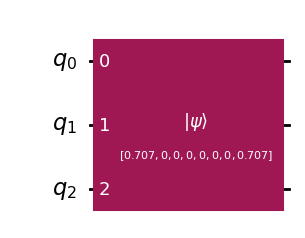

None


/tmp/ipykernel_128853/3825082433.py:17: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService()
/home/caiosiq/.conda/envs/qpa_env/lib/python3.10/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1129: UserWarning: IBM Quantum Platform is moving, and this version will be sunset on July 1. To get started on the new platform, read the migration guide at https://docs.quantum.ibm.com/migration-guides/classic-iqp-to-cloud-iqp
  warnings.warn(warning_message)


In [ ]:
from qiskit import QuantumCircuit,transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector
import numpy as np

# Define the amplitudes for the statevector of 3 qubits (8 elements)
psi = [1/np.sqrt(2) if i in [0, 7] else 0 for i in range(8)]
qc = QuantumCircuit(3)
qc.initialize(psi, [0, 1, 2])  # Apply to qubits 0, 1, 2
# qc.barrier()
# qc.h(0)
# qc.cx(0, 1)  # Example: apply further gates if needed
print(display(qc.draw('mpl')))
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeBrisbane

service = QiskitRuntimeService()
# backend = FakeSherbrooke()
backend = service.backend("ibm_sherbrooke")
qc = transpile(qc, backend=backend, optimization_level=3)
# Define observable
observable = SparsePauliOp("ZZZ")

layout = qc.layout
observable = observable.apply_layout(layout)
# Transpile and prepare Estimator
# qc.save_statevector()  # Optional: save statevector for inspection
estimator = EstimatorV2(mode=backend)

# Run the estimator
job = estimator.run([(qc, observable)])
result = job.result()
expectation_value = result[0].data.evs

print("⟨ZZZ⟩ =", expectation_value)


In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel='ibm_quantum',
    instance='research-credits/100698/main',
)
job = service.job('d18zdjymya700087eaj0')
job_result = job.result()

for idx, pub_result in enumerate(job_result):
    print(f"Expectation values for pub {idx}: {pub_result.data.evs}")

/tmp/ipykernel_171661/1078618506.py:3: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService(


Expectation values for pub 0: -0.042459088898717384


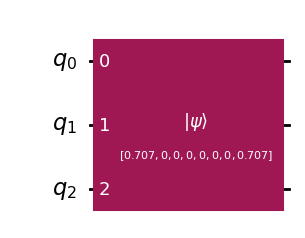

None
⟨ZZZ⟩ = 0.0


In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# Define the amplitudes for the statevector of 3 qubits (8 elements)
psi = [1/np.sqrt(2) if i in [0, 7] else 0 for i in range(8)]
qc = QuantumCircuit(3)
qc.initialize(psi, [0, 1, 2])  # Apply to qubits 0, 1, 2
# qc.barrier()
# qc.h(0)
# qc.cx(0, 1)  # Example: apply further gates if needed
print(display(qc.draw('mpl')))
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

# Define observable
observable = SparsePauliOp("ZZZ")

# Transpile and prepare Estimator
qc.save_statevector()  # Optional: save statevector for inspection
estimator = AerEstimator()

# Run the estimator
job = estimator.run([(qc, observable)])
result = job.result()
expectation_value = result[0].data.evs

print("⟨ZZZ⟩ =", expectation_value)


In [2]:
import numpy as np
rho = np.load("/home/submit/caiosiq/qpa/purification/shared_data/rho/rho_k4_V40_Om3_Del-4to4_ramp0.33_0.34_0.33_T6.npy")

In [3]:
print(rho)

[[ 1.55908674e-03+1.28771861e-15j  2.04737634e-04+2.96885066e-04j
   2.04737634e-04+2.96885066e-04j  1.43242308e-06+4.96775278e-06j
   2.04737634e-04+2.96885066e-04j  1.06687118e-02+4.21706488e-03j
   1.43242308e-06+4.96775278e-06j -3.70096292e-07-1.45231718e-06j
   2.04737634e-04+2.96885066e-04j  1.43242308e-06+4.96775278e-06j
   1.06687118e-02+4.21706488e-03j -3.70096292e-07-1.45231718e-06j
   1.43242308e-06+4.96775278e-06j -3.70096292e-07-1.45231718e-06j
  -3.70096292e-07-1.45231718e-06j -1.36361856e-10+2.30979934e-10j]
 [ 2.04737634e-04-2.96885066e-04j  1.25387808e-02-2.77636815e-16j
   2.93664171e-03-6.01083357e-16j  2.11458500e-06-1.01418018e-05j
  -2.57947878e-03-1.58423363e-15j -1.31063035e-02-5.12278989e-03j
  -3.71857988e-06-6.51296748e-06j  5.30401028e-07+2.05561168e-06j
   2.93664171e-03-6.97274142e-16j  2.11458500e-06-1.01418018e-05j
  -1.13351746e-02-8.94762058e-03j  1.92040916e-07+2.17623089e-06j
  -3.71857988e-06-6.51296748e-06j  5.30401028e-07+2.05561168e-06j
  -1.4703

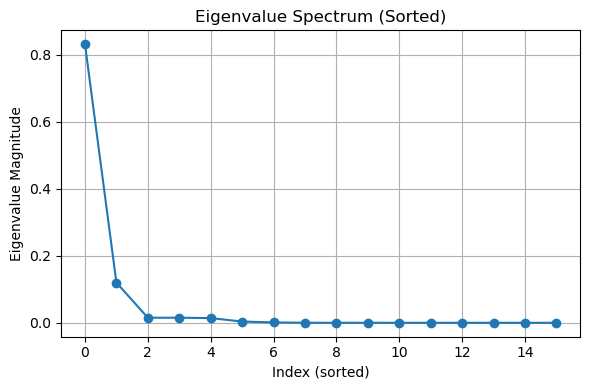

array([8.30767859e-01, 1.19922670e-01, 1.51182659e-02, 1.51182659e-02,
       1.40093475e-02, 3.77927240e-03, 1.11354783e-03, 5.73953832e-05,
       3.12213069e-05, 3.12213069e-05, 1.07191050e-05, 1.05530145e-05,
       1.05530145e-05, 1.03822712e-05, 8.72492413e-06, 6.29414174e-10])

In [4]:
import sympy as sp
import matplotlib.pyplot as plt
# Use real part if matrix is symmetric or Hermitian; otherwise, use absolute value
eigvals, eigvecs = np.linalg.eigh(rho)
spectrum = np.sort(np.abs(eigvals))[::-1]  # descending order


# Plot spectrum
plt.figure(figsize=(6, 4))
plt.plot(spectrum, marker='o', linestyle='-')
plt.title('Eigenvalue Spectrum (Sorted)')
plt.xlabel('Index (sorted)')
plt.ylabel('Eigenvalue Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()
spectrum 

In [5]:
sorted_indices = np.argsort(eigvals)[::-1]
print(sorted_indices)
# Apply sorting
eigvals_sorted = eigvals[sorted_indices]
eigvecs_sorted = eigvecs[:, sorted_indices]

# Print sorted eigenvalues and eigenvectors
print("Sorted Eigenvalues:")
print(eigvals_sorted)

print("\nSorted Eigenvectors:")
print(eigvecs_sorted)
print(eigvecs_sorted[0].shape)

[15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]
Sorted Eigenvalues:
[8.30767859e-01 1.19922670e-01 1.51182659e-02 1.51182659e-02
 1.40093475e-02 3.77927240e-03 1.11354783e-03 5.73953832e-05
 3.12213069e-05 3.12213069e-05 1.07191050e-05 1.05530145e-05
 1.05530145e-05 1.03822712e-05 8.72492413e-06 6.29414174e-10]

Sorted Eigenvectors:
[[ 1.95195007e-02+0.00000000e+00j  4.84072214e-15+0.00000000e+00j
   1.87852857e-13+0.00000000e+00j -4.59293716e-14+0.00000000e+00j
   1.00183632e-01-0.00000000e+00j -9.99759801e-14+0.00000000e+00j
  -9.94777248e-01+0.00000000e+00j -6.63766413e-04+0.00000000e+00j
   5.06179579e-14+0.00000000e+00j -2.89005530e-14+0.00000000e+00j
   1.19565074e-04+0.00000000e+00j  6.65459033e-15+0.00000000e+00j
   3.63022900e-15+0.00000000e+00j  2.60491202e-14+0.00000000e+00j
  -3.28293317e-14+0.00000000e+00j -4.24376521e-08+0.00000000e+00j]
 [-2.41651113e-02-3.60744348e-03j  2.00120353e-02-1.61181020e-02j
   3.35850605e-01-5.74665477e-01j -8.85508934e-02+2.21635945e-01j
  

In [6]:
### Calculate Fidelity theoretically

input_state = eigvecs_sorted[:,0]

print(input_state)
psi_target = [0]*16
psi_target[int('0101',2)] =1
psi_target[int('1010',2)] =1
psi_target = psi_target/np.linalg.norm(psi_target)
print(psi_target)
exact_state = Statevector(psi_target)
print(exact_state)

pfidelity = np.abs(np.vdot(psi_target, input_state))**2
print(pfidelity)



[ 1.95195007e-02+0.00000000e+00j -2.41651113e-02-3.60744348e-03j
 -2.41651113e-02-3.60744348e-03j  1.00835731e-04-3.26393404e-04j
 -2.41651113e-02-3.60744348e-03j  6.57192997e-01-2.58287969e-01j
  1.00835731e-04-3.26393404e-04j -2.65972257e-05+9.31361999e-05j
 -2.41651113e-02-3.60744348e-03j  1.00835731e-04-3.26393404e-04j
  6.57192997e-01-2.58287969e-01j -2.65972257e-05+9.31361999e-05j
  1.00835731e-04-3.26393404e-04j -2.65972257e-05+9.31361999e-05j
 -2.65972257e-05+9.31361999e-05j -5.58909277e-09-1.37070938e-08j]
[0.         0.         0.         0.         0.         0.70710678
 0.         0.         0.         0.         0.70710678 0.
 0.         0.         0.         0.        ]
Statevector([0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
  

In [7]:
k=4
basis_size = 2 ** k
d = basis_size
psi_target = [0]*16
psi_target[int('0101',2)] =1
psi_target[int('1010',2)] =1
psi_target = psi_target/np.linalg.norm(psi_target)


eigvals, eigvecs = np.linalg.eigh(rho)
#principle eigenvector fidelity
principal_index = np.argmax(eigvals)
print(principal_index)
psi_principal = eigvecs[:, principal_index]
print(psi_principal)
pfidelity = np.abs(np.vdot(psi_target, psi_principal))**2
print(pfidelity)

15
[ 1.95195007e-02+0.00000000e+00j -2.41651113e-02-3.60744348e-03j
 -2.41651113e-02-3.60744348e-03j  1.00835731e-04-3.26393404e-04j
 -2.41651113e-02-3.60744348e-03j  6.57192997e-01-2.58287969e-01j
  1.00835731e-04-3.26393404e-04j -2.65972257e-05+9.31361999e-05j
 -2.41651113e-02-3.60744348e-03j  1.00835731e-04-3.26393404e-04j
  6.57192997e-01-2.58287969e-01j -2.65972257e-05+9.31361999e-05j
  1.00835731e-04-3.26393404e-04j -2.65972257e-05+9.31361999e-05j
 -2.65972257e-05+9.31361999e-05j -5.58909277e-09-1.37070938e-08j]
0.9972306197469408


In [10]:
#Code to get a list of all possible state combinations
def task(List,sampler):
    finalList = []
    for group in List:
        newgroups = [(*group,x) for x in sampler]
        finalList.extend(newgroups)
    return finalList
def create_List(k,sampler):
    list = [(i,) for i in sampler]
    for i in range(1,k):
        list = task(list,sampler)
    return list
nstates = 2
nreg=3
possible_indices_list = create_List(nreg,range(nstates))
states_list = []
probs_list = []

for possible_indices in possible_indices_list:
    states = [eigvecs_sorted[:, index] for index in possible_indices]
    prob = np.prod([eigvals_sorted[index] for index in possible_indices])
    states_list.append(states)
    probs_list.append(prob)

# === Save the data ===
np.savez("/home/submit/caiosiq/qpa/purification/shared_data/ryd_estimations/all_states.npz", states=states_list, probs=probs_list)

print(f"Saved {len(states_list)} entries to all_states.npz")

    



Saved 8 entries to all_states.npz


In [11]:
np.savez("/home/submit/caiosiq/qpa/purification/shared_data/ryd_estimations/exact_state.npz", state=exact_state)

In [14]:
input_index = 0
datafile = "/home/submit/caiosiq/qpa/purification/shared_data/ryd_estimations/all_states.npz"
data = np.load(datafile, allow_pickle=True)
input_states = data["states"][input_index]


exact_state_file = "/home/submit/caiosiq/qpa/purification/shared_data/ryd_estimations/exact_state.npz"
exact_state_data = np.load(exact_state_file, allow_pickle=True)
exact_state = exact_state_data["state"]

pfidelity = np.abs(np.vdot(input_states[0], exact_state))**2
print(pfidelity)

0.9972306197469406
